# **Wine Classification Using Machine Learning**

Mini Project: Wine Classification Using Machine Learning

Random Forest

Problem Statement

Given the Wine Dataset, which contains 13 chemical features measured from wine samples. Each wine belongs to one of three classes (0, 1, 2), representing three different wine cultivars.

The task is to build, tune, evaluate, and compare Decision Tree and Random Forest models to correctly classify wine samples into their respective classes.

Firstly importing the Packages.

And Loading the wine Dataset.

In [ ]:
# Wine Dataset: Ensemble & Boosting
# ===============================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn models & metrics
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
# Seaborn style
sns.set(style="whitegrid")


# -------------------------------
# 2️⃣ Load Wine Dataset
# -------------------------------
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

# Display first few rows
display(X.head())
print("Target classes:", np.unique(y))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Target classes: [0 1 2]


Random Forest with feature Importance + Tree Visualisation.

Now Training the Dataset and Testing the Dataset by Splitting.

In [ ]:
# ===============================
# RANDOM FOREST with Feature Importance + Tree Visualization
# ===============================

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# ===============================
# Model
# ===============================
rf = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees in the forest

    max_depth=None,        # Each tree can grow fully (no depth limit)


    bootstrap=True,        # Sampling WITH replacement (required for OOB score)
                          # Each tree gets a random subset of data

    oob_score=True,        # Enables Out-of-Bag evaluation
                          # Gives a validation accuracy without needing train-test split

    random_state=42        # Ensures reproducible results
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
print("Prediction classes of new wine samples:", y_pred_rf)


# ===============================
# Metrics
# ===============================
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("OOB Score (Out-of-Bag estimate):", rf.oob_score_)



Prediction classes of new wine samples: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
Random Forest Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

OOB Score (Out-of-Bag estimate): 0.9788732394366197


Visualize one tree from random forest

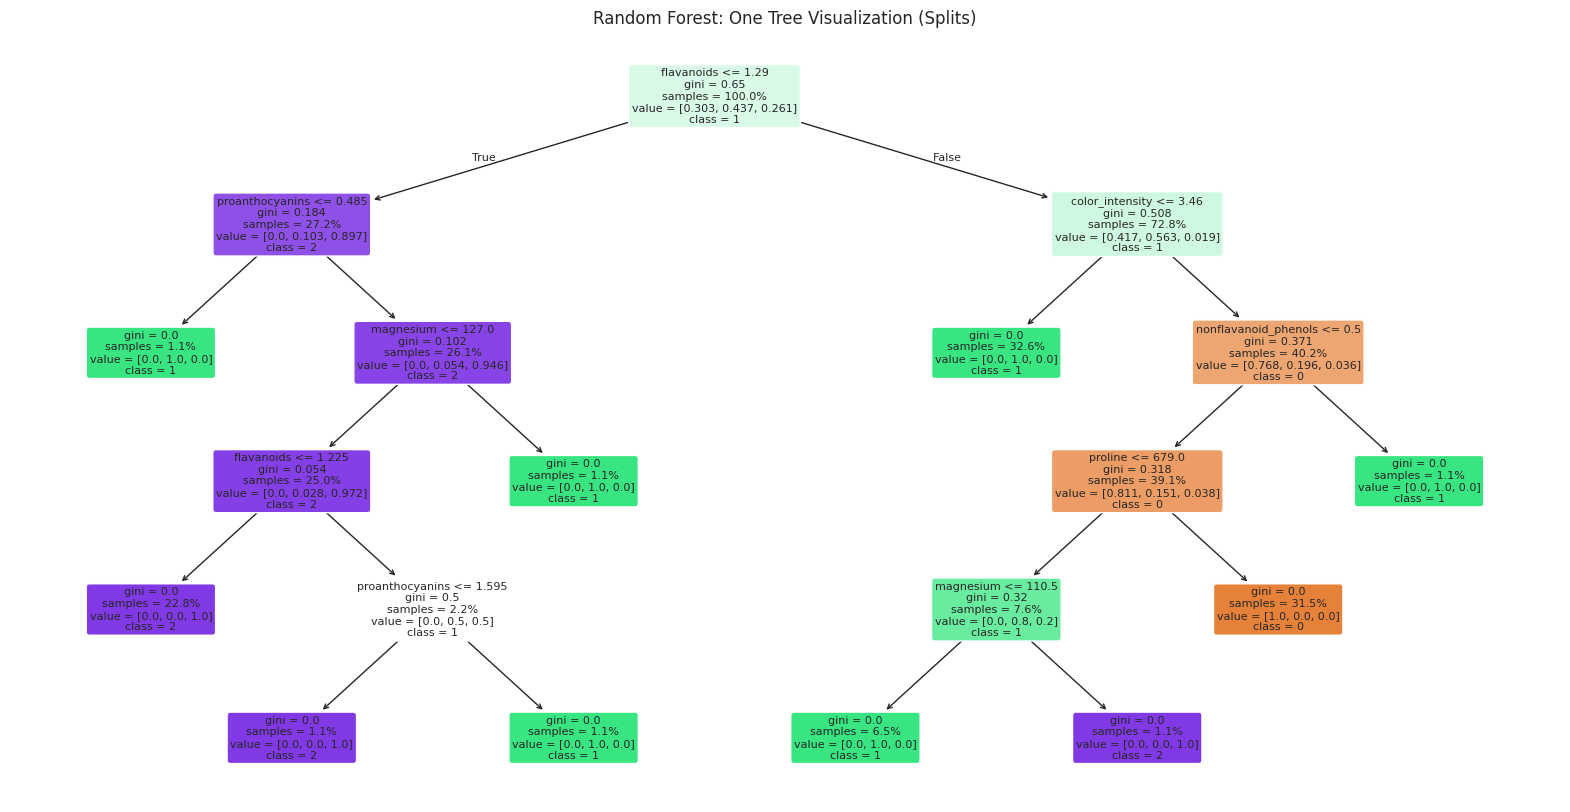

In [ ]:
# ===============================
# Visualize ONE tree from Random Forest
# ===============================
one_tree = rf.estimators_[1]  # pick the first tree or 99 tre

plt.figure(figsize=(20, 10))
plot_tree(
    one_tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in y.unique()],#Convert numeric class labels → string labels for decision tree visualization.
    filled=True,#Fills each node with a color.
    rounded=True,
    proportion=True,#Shows the percentage of samples in each node instead of the absolute count.
    fontsize=8
)
plt.title("Random Forest: One Tree Visualization (Splits)")
plt.show()

Boosting

In [ ]:
# ===============================
# Boosting on Wine Dataset
# ===============================

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# AdaBoost Classifier (Boosting)
# ===============================
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

# Predictions
y_pred_ada = ada.predict(X_test)

# Metrics
print("=== AdaBoost Results ===")
acc_ada = accuracy_score(y_test, y_pred_ada)
print("Accuracy:", acc_ada)
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))




=== AdaBoost Results ===
Accuracy: 0.9722222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


Gradient Boosting Classifier

In [ ]:
# ===============================
# Gradient Boosting Classifier
# ===============================
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)

# Metrics
print("\n=== Gradient Boosting Results ===")
acc_gb = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", acc_gb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

# Define acc_boost to be used in the comparison plot
acc_boost = acc_ada # Using AdaBoost's accuracy for the general 'Boosting' category


=== Gradient Boosting Results ===
Accuracy: 0.9444444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]


Feature Importance Plot (GB is better)

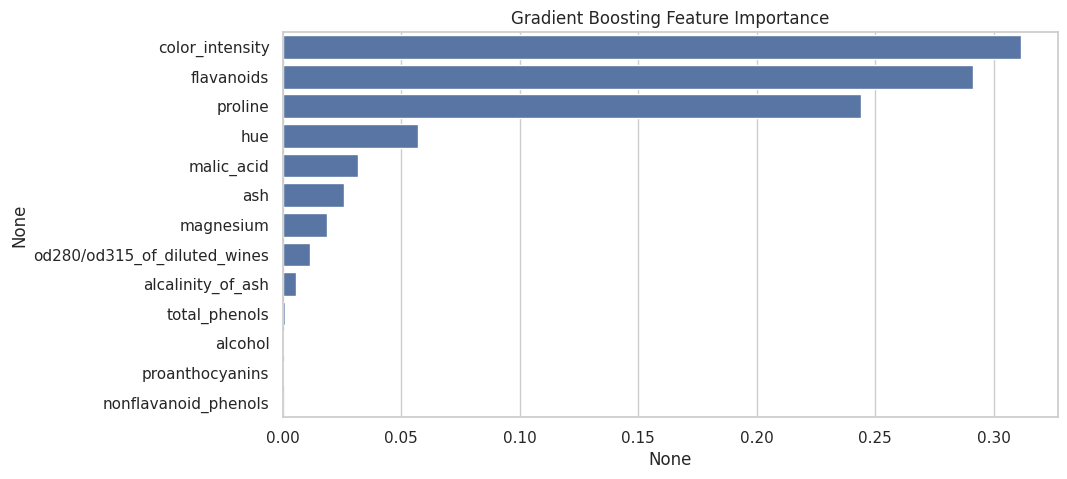


Boosting Explanation:
- Boosting builds trees sequentially, not in parallel.
- Each new tree focuses on mistakes made by previous trees.
- AdaBoost: Adjusts sample weights after each weak learner.
- Gradient Boosting: Uses gradient descent on the loss function.
- Result: Lower bias, more powerful than Bagging, but can overfit if not tuned.



In [ ]:
# ===============================
# Feature Importance Plot (GB is better)
# ===============================
plt.figure(figsize=(10, 5))
feature_importance_gb = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

sns.barplot(x=feature_importance_gb, y=feature_importance_gb.index)
plt.title("Gradient Boosting Feature Importance")
plt.show()

# ===============================
# Boosting Explanation
# ===============================
print("""
Boosting Explanation:
- Boosting builds trees sequentially, not in parallel.
- Each new tree focuses on mistakes made by previous trees.
- AdaBoost: Adjusts sample weights after each weak learner.
- Gradient Boosting: Uses gradient descent on the loss function.
- Result: Lower bias, more powerful than Bagging, but can overfit if not tuned.
""")


Stochastic Gradient Boosting Trees (SGBT)

In [ ]:
# ===============================
# Stochastic Gradient Boosting Trees (SGBT)
# ===============================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import pandas as pd

# -------------------------------
# Dataset
# -------------------------------
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Stochastic Gradient Boosting
# -------------------------------
#In scikit-learn, there is no separate class for “Stochastic Gradient Boosting.”You use the same class: GradientBoostingClassifier.
#just include --subsample.
sgb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,     # depth of each weak learner
    subsample=0.8,   # ✅ stochastic: 80% samples per tree
    random_state=42
)
sgb_model.fit(X_train, y_train)

# Predictions
y_pred_sgb = sgb_model.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
acc_sgb = accuracy_score(y_test, y_pred_sgb)
print("SGBT Test Accuracy:", acc_sgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_sgb))

print("""
Concept:
- Gradient Boosting builds trees sequentially, each correcting errors of the previous.
- 'Stochastic' comes from subsample < 1.0 (here 0.8), which introduces randomness.
- This reduces variance and improves generalization compared to plain boosting.
""")


SGBT Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Concept:
- Gradient Boosting builds trees sequentially, each correcting errors of the previous.
- 'Stochastic' comes from subsample < 1.0 (here 0.8), which introduces randomness.
- This reduces variance and improves generalization compared to plain boosting.



Decision Tree vs Random Forest vs AdaBoost vs Gradient Boosting (SGBDT)


===== Model Reports =====
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

AdaBoost Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.92      0.86     

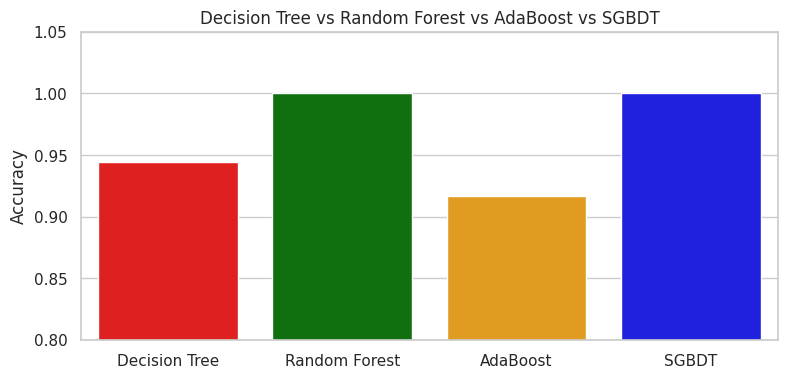


Bias-Variance Intuition:
- Decision Tree: Low bias, high variance (prone to overfitting).
- Random Forest: Bagging + feature randomness → lower variance, stable.
- AdaBoost: Sequentially corrects mistakes → reduces bias.
- SGBDT: Gradient boosting + stochastic subsampling → reduces both bias & variance, more robust than AdaBoost.



In [ ]:
# ===============================
# Decision Tree vs Random Forest vs AdaBoost vs Gradient Boosting (SGBDT)
# ===============================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Dataset
# -------------------------------
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 1️⃣ Decision Tree
# -------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# -------------------------------
# 2️⃣ Random Forest
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# -------------------------------
# 3️⃣ AdaBoost (Boosting)
# -------------------------------
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)
acc_boost = accuracy_score(y_test, y_pred_boost)

# -------------------------------
# 4️⃣ Stochastic Gradient Boosting (SGBDT)
# -------------------------------
sgb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,       # ✅ stochastic: use 80% of samples per tree
    random_state=42
)
sgb_model.fit(X_train, y_train)
y_pred_sgb = sgb_model.predict(X_test)
acc_sgb = accuracy_score(y_test, y_pred_sgb)

# -------------------------------
# 5️⃣ Reports
# -------------------------------
print("\n===== Model Reports =====")
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("AdaBoost Report:\n", classification_report(y_test, y_pred_boost))
print("Stochastic Gradient Boosting Report:\n", classification_report(y_test, y_pred_sgb))

# -------------------------------
# 6️⃣ Accuracy Comparison
# -------------------------------
print("\n===== Accuracy Comparison =====")
print(f"Decision Tree Accuracy : {acc_dt:.3f}")
print(f"Random Forest Accuracy : {acc_rf:.3f}")
print(f"AdaBoost Accuracy      : {acc_boost:.3f}")
print(f"SGBDT Accuracy         : {acc_sgb:.3f}")
print(f"Random Forest OOB Score: {rf_model.oob_score_:.3f}")

# -------------------------------
# 7️⃣ Visualization
# -------------------------------
plt.figure(figsize=(9,4))
sns.barplot(
    x=["Decision Tree", "Random Forest", "AdaBoost", "SGBDT"],
    y=[acc_dt, acc_rf, acc_boost, acc_sgb],
    hue=["Decision Tree", "Random Forest", "AdaBoost", "SGBDT"],  # ✅ fix for seaborn future warning
    palette=["red", "green", "orange", "blue"],
    legend=False
)
plt.ylim(0.8, 1.05)
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest vs AdaBoost vs SGBDT")
plt.show()

# -------------------------------
# 8️⃣ Conceptual Notes
# -------------------------------
print("""
Bias-Variance Intuition:
- Decision Tree: Low bias, high variance (prone to overfitting).
- Random Forest: Bagging + feature randomness → lower variance, stable.
- AdaBoost: Sequentially corrects mistakes → reduces bias.
- SGBDT: Gradient boosting + stochastic subsampling → reduces both bias & variance, more robust than AdaBoost.
""")
